In [1]:
# STAT 604 HW6 Duncan Newman

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t, norm

In [2]:
columns = ["Sex","Length","Diameter","Height","WholeWeight",
           "ShuckedWeight","VisceraWeight","ShellWeight","Rings"]

df = pd.read_csv("abalone.data", header=None, names=columns)

length = df["Length"].values

N = len(length)

print("Total records:", N)

Total records: 4177


In [3]:
population_mean = np.mean(length)
print("Population Mean:", population_mean)

Population Mean: 0.5239920995930094


In [4]:
# 1a

n_sim = 10000
n = 20
count = 0

for i in range(n_sim):

    sample = np.random.choice(length, n, replace=True)

    sample_mean = np.mean(sample)
    s = np.std(sample, ddof=1)

    t_crit = t.ppf(0.95, df=n-1)

    margin = t_crit * s / np.sqrt(n)

    lower = sample_mean - margin
    upper = sample_mean + margin

    if lower <= population_mean <= upper:
        count += 1

coverage_1a = count / n_sim
print("Coverage fraction (n=20, t):", coverage_1a)

Coverage fraction (n=20, t): 0.8976


In [5]:
# 1b

n = 10
count = 0

for i in range(n_sim):

    sample = np.random.choice(length, n, replace=True)

    sample_mean = np.mean(sample)
    s = np.std(sample, ddof=1)

    t_crit = t.ppf(0.95, df=n-1)

    margin = t_crit * s / np.sqrt(n)

    lower = sample_mean - margin
    upper = sample_mean + margin

    if lower <= population_mean <= upper:
        count += 1

coverage_1b = count / n_sim
print("Coverage fraction (n=10, t):", coverage_1b)

Coverage fraction (n=10, t): 0.8896


In [6]:
#1c

n = 10
count = 0

for i in range(n_sim):

    sample = np.random.choice(length, n, replace=True)

    sample_mean = np.mean(sample)
    s = np.std(sample, ddof=1)

    z_crit = norm.ppf(0.95)

    margin = z_crit * s / np.sqrt(n)

    lower = sample_mean - margin
    upper = sample_mean + margin

    if lower <= population_mean <= upper:
        count += 1

coverage_1c = count / n_sim
print("Coverage fraction (n=10, normal):", coverage_1c)

Coverage fraction (n=10, normal): 0.8612


In [7]:
# 1d

n = 3

count_t = 0
count_normal = 0

for i in range(n_sim):

    sample = np.random.choice(length, n, replace=True)

    sample_mean = np.mean(sample)
    s = np.std(sample, ddof=1)

    # t interval
    t_crit = t.ppf(0.95, df=n-1)
    margin_t = t_crit * s / np.sqrt(n)

    lower_t = sample_mean - margin_t
    upper_t = sample_mean + margin_t

    if lower_t <= population_mean <= upper_t:
        count_t += 1

    # normal interval
    z_crit = norm.ppf(0.95)
    margin_z = z_crit * s / np.sqrt(n)

    lower_z = sample_mean - margin_z
    upper_z = sample_mean + margin_z

    if lower_z <= population_mean <= upper_z:
        count_normal += 1

print("Coverage (n=3, t):", count_t/n_sim)
print("Coverage (n=3, normal):", count_normal/n_sim)

Coverage (n=3, t): 0.8783
Coverage (n=3, normal): 0.7464


In [8]:
population_median = np.median(length)
print("Population Median:", population_median)

Population Median: 0.545


In [9]:
def bootstrap_ci(sample, B=1000):

    medians = []

    for i in range(B):
        resample = np.random.choice(sample, len(sample), replace=True)
        medians.append(np.median(resample))

    lower = np.percentile(medians, 5)
    upper = np.percentile(medians, 95)

    return lower, upper

In [21]:
def bootstrap_coverage(sample_size, simulations=10000, B=1000):

    count = 0

    for _ in range(simulations):

        sample = np.random.choice(length, sample_size, replace=True)

        # generate all bootstrap samples at once
        resamples = np.random.choice(sample, size=(B, sample_size), replace=True)

        medians = np.median(resamples, axis=1)

        lower = np.percentile(medians, 5)
        upper = np.percentile(medians, 95)

        if lower <= population_median <= upper:
            count += 1

    return count / simulations

In [22]:
# 2a

coverage_2a = bootstrap_coverage(100)
print("Coverage (n=100):", coverage_2a)

Coverage (n=100): 0.9108


In [23]:
# 2b

coverage_2b = bootstrap_coverage(30)
print("Coverage (n=30):", coverage_2b)

Coverage (n=30): 0.9029


In [24]:
# 2c

coverage_2c = bootstrap_coverage(10)
print("Coverage (n=10):", coverage_2c)

Coverage (n=10): 0.8824


In [12]:
scores = np.array([
3.8,3.0,4.0,4.8,3.0,
4.2,3.5,4.7,4.4,4.2,
4.3,3.8,3.3,4.0,3.8
])

n = len(scores)
mean = np.mean(scores)
s = np.std(scores, ddof=1)

In [13]:
# 3a

t_crit = t.ppf(0.975, df=n-1)

margin = t_crit * s / np.sqrt(n)

ci_t = (mean - margin, mean + margin)

print("95% CI (t):", ci_t)

95% CI (t): (np.float64(3.6158159675735457), np.float64(4.224184032426454))


In [14]:
# 3b

B = 1000
boot_means = []

for i in range(B):
    resample = np.random.choice(scores, n, replace=True)
    boot_means.append(np.mean(resample))

ci_boot = (
    np.percentile(boot_means, 2.5),
    np.percentile(boot_means, 97.5)
)

print("Bootstrap CI:", ci_boot)

Bootstrap CI: (np.float64(3.6464999999999996), np.float64(4.186833333333333))


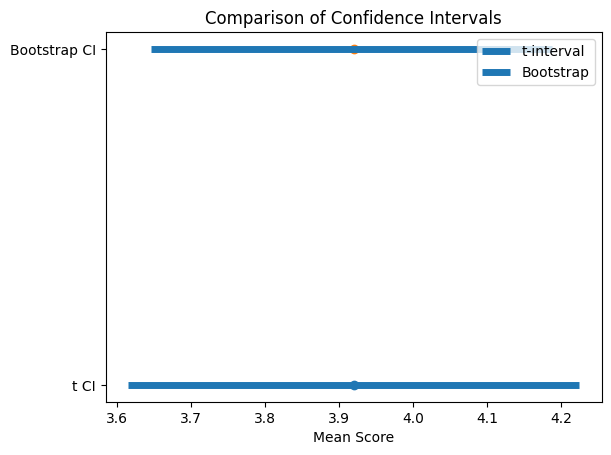

In [15]:
# 3c

plt.figure()

plt.hlines(1, ci_t[0], ci_t[1], linewidth=5, label="t-interval")
plt.hlines(2, ci_boot[0], ci_boot[1], linewidth=5, label="Bootstrap")

plt.scatter(mean,1)
plt.scatter(mean,2)

plt.yticks([1,2],["t CI","Bootstrap CI"])
plt.xlabel("Mean Score")
plt.title("Comparison of Confidence Intervals")

plt.legend()
plt.show()

In [16]:
n = 5924
x = 153

p_hat = x/n

In [17]:
# 4a

z = norm.ppf(0.95)

den = 1 + z**2/n

center = (p_hat + z**2/(2*n)) / den

margin = z * np.sqrt((p_hat*(1-p_hat)/n) + z**2/(4*n**2)) / den

wilson_ci = (center - margin, center + margin)

print("Wilson CI:", wilson_ci)

Wilson CI: (np.float64(0.02264765753912011), np.float64(0.02943955030184532))


In [18]:
# 4c

data = np.array([1]*153 + [0]*(5924-153))

B = 1000
boot_props = []

for i in range(B):

    resample = np.random.choice(data, n, replace=True)

    boot_props.append(np.mean(resample))

boot_ci = (
    np.percentile(boot_props, 5),
    np.percentile(boot_props, 95)
)

print("Bootstrap CI:", boot_ci)

Bootstrap CI: (np.float64(0.02261141120864281), np.float64(0.02937204591492235))


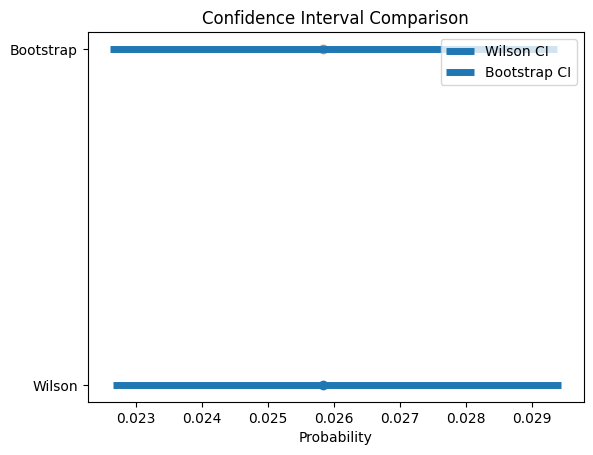

In [19]:
# 4d

plt.figure()

plt.hlines(1, wilson_ci[0], wilson_ci[1], linewidth=5, label="Wilson CI")
plt.hlines(2, boot_ci[0], boot_ci[1], linewidth=5, label="Bootstrap CI")

plt.scatter(p_hat,1)
plt.scatter(p_hat,2)

plt.yticks([1,2],["Wilson","Bootstrap"])
plt.xlabel("Probability")
plt.title("Confidence Interval Comparison")

plt.legend()
plt.show()